# Create labels randomly within specific categories

Example notebook to show how to use and apply a **random sampling** based on the **som bmu clusters** (or any other integer grid if provided).<br>
Functionality can be used to both:
- Extent the existing positive labels with additional points sampled from specified categories
- Add new negative labels sampled from the specified "background" categories

Options for **selecting** categories::
- Absolute thresholds, values larger than 1: cut-off categories lower/upper the provided threshold
- Quantiles, values between [0, 1]: cut-off categories lower/upper the provided quantile
- Discrete selection: list of categories to keep

Options for **sampling**:
- Sample each class separately based on a fraction of the total number of available points in a cluster
- Sample based on a merged cluster, which is created temporarily and then used to sample the specified number of points

After sampling, the **additional labels** must be **merged** with the existing labels for the respective class (positives/negatives)


## General

In [70]:
# set working directory and data folder
import os

# set working directory
data_folder = os.path.join(os.getcwd(), "data")


## Load data

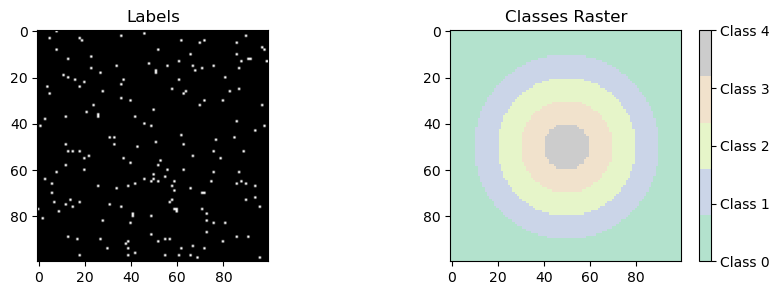

In [71]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from beak.utilities.file_io import read_raster_band

base_array, base_meta = read_raster_band(rasterio.open(os.path.join(data_folder, "base_raster.tif")))
labels_array, labels_meta = read_raster_band(rasterio.open(os.path.join(data_folder, "label_raster.tif")))

cats_path = os.path.join(data_folder, "classes_raster.tif")
cats_array, cats_meta = read_raster_band(rasterio.open(cats_path))

# Plot
ncols = 2
fig_size = ncols * 5

cats_values = np.unique(cats_array)
cats_cmap = plt.get_cmap("Pastel2", len(cats_values))
cats_ticks = cats_values

fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=(fig_size, 3))
ax[0].imshow(labels_array, cmap="gray")
ax[0].set_title("Labels")

# Store the imshow result
cats_img = ax[1].imshow(cats_array, cmap=cats_cmap, interpolation='nearest')

# Create the colorbar using the mappable object
cats_bar = fig.colorbar(cats_img, ax=ax[1], ticks=cats_ticks)

# Set class labels if needed
class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']
cats_bar.ax.set_yticklabels(class_labels)

ax[1].set_title("Classes Raster")

plt.show()

## Check actual classes

In [72]:
from beak.experimental.preparation import _get_unique_values_list

classes, counts = _get_unique_values_list(cats_array, verbose=1)

Class: 0.0, Count: 4987
Class: 1.0, Count: 2204
Class: 2.0, Count: 1564
Class: 3.0, Count: 940
Class: 4.0, Count: 305


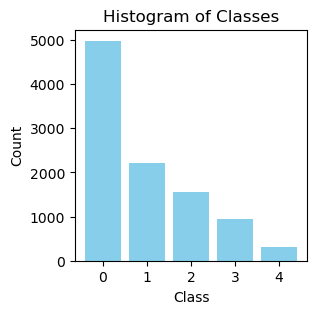

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.bar(classes, counts, color='skyblue')
plt.xticks(classes)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Histogram of Classes')
plt.show()

## Sampling

According to our conventions, negative labels have a value of **0** and positive labels have a value of **1**.<p>
Adding **new** labels to the existing ones, we need to **select** which **classes** we want to use for sampling, either for the **positives** or **negatives**.<p>

For the following examples, we will
- sample from **Class 0** for the **negatives**
- sample from **Classes 1 and higher** for the **positives**

We will **exclude** any **class** here, but could do this using the `exclude_classes` parameter.

The sampling is based on **three steps**:
- **Selection** of relevant classes: mandatory to ensure that only relevant classes are selected
- **Sampling** from these classes
- **Merge** with existing labels:
  - negatives are intended to **replace** the existing negatives
  - positives are intended to be **added** to the existing positives

The **sampling** can be done by both using the **raster's path** (`_sampling_by_selection` or `_sampling_by_threshold`) or using the **cluster map**, which can be an already loaded raster array (`_sampling_select_classes`).

### Negatives

**Selection** of pixels can be done as follows:
- Threshold via `_sampling_by_treshold` and `type="negatives"` with value **1** (selects all values below)
- Quantile via `sampling_by_threshold` and `type="negatives"` in range [0, 1] (**not** appropriate)
- Discrete selection via `_sampling_by_selection` using the `include` parameter with value **[0]**
- Discrete selection via `_sampling_by_selection` using the `exclude` parameter with all values except **0**<p>

**Please not that this procedure aims to replace the existing negatives with the selected ones.**<br>
E.g., this means, the resulting negatives will `value = 0` and remaining pixels will be `value = np.nan`.

In [74]:
SELECTION = [0, 1, 2]       # Option A: selects classes/values 0, 1, 2
THRESHOLD = 3               # Option B: selects values below 3

TARGET_NEGATIVES = 0        # Sets the value for the sampled negatives

CLUSTER_MAP = cats_path

#### Option A
**Selection** using `_sampling_by_selection`<p>
We use a **different sampling strategy** for each class, decreasing from outer to inner classes:<br>
- 50% for class 0
- 25% for class 1
- 10% for class 2

In [75]:
from beak.experimental.preparation import _sampling_by_selection

# Selection of pixels
selection_array_a, selection_settings_a = _sampling_by_selection(CLUSTER_MAP, include=SELECTION)
classes_a, counts_a = _get_unique_values_list(selection_array_a, include_nan=True, verbose=1)


Class: 0.0, Count: 4987
Class: 1.0, Count: 2204
Class: 2.0, Count: 1564
Class: nan, Count: 1245


**Sampling**

In [76]:
from beak.experimental.preparation import _sampling_select_random_points

# Sampling
new_negatives_a, neg_dict_a = _sampling_select_random_points(array=selection_array_a,         # the prepared array
                                                             selection=SELECTION,             # the classes to sample from
                                                             strategy=[0.5, 0.25, 0.1],       # the fraction(s) to sample
                                                             target_value=TARGET_NEGATIVES,   # the output value for sampled pixels
                                                             merge_classes=False,             # merge before sampling or not
                                                             min_px=1,                        # minimum number of pixels to sample
                                                             seed=42,                         # seed for reproducibility
)

# Get unique values
_, _ = _get_unique_values_list(new_negatives_a, include_nan=True, verbose=1)

Class: 0.0, Count: 3201
Class: nan, Count: 6799


#### Option B
**Selection** using `_sampling_by_threshold`

We use the  **same sampling strategy** for each class, however, even using the `threshold` parameter, different strategies as in **Option A** can be used:<br>
- 50% for all selected classes


In [77]:
from beak.experimental.preparation import _sampling_by_threshold

# Selection of pixels with class 0
selection_array_b, settings_b = _sampling_by_threshold(CLUSTER_MAP, type="negatives", threshold=THRESHOLD, exclude=None)
classes_b, counts_b = _get_unique_values_list(selection_array_b, include_nan=True, verbose=1)


Class: 0.0, Count: 4987
Class: 1.0, Count: 2204
Class: 2.0, Count: 1564
Class: nan, Count: 1245


**Sampling**

In [78]:
from beak.experimental.preparation import _sampling_select_random_points

# Sampling: values specified in SELECTION must be contained in the resulting array
new_negatives_b, neg_dict_b = _sampling_select_random_points(array=selection_array_b,                               # the prepared array
                                                             selection=list(np.arange(0, THRESHOLD)),               # the classes to sample from
                                                             strategy=[0.5],                                        # the fraction to sample (50%)
                                                             target_value=TARGET_NEGATIVES,                         # the output value for sampled pixels
                                                             merge_classes=False,                                   # merge before sampling or not
                                                             min_px=1,                                              # minimum number of pixels to sample
                                                             seed=42,                                               # seed for reproducibility
)

# Get unique values
_, _ = _get_unique_values_list(new_negatives_b, include_nan=True, verbose=1)

Class: 0.0, Count: 4378
Class: nan, Count: 5622


#### Comparison

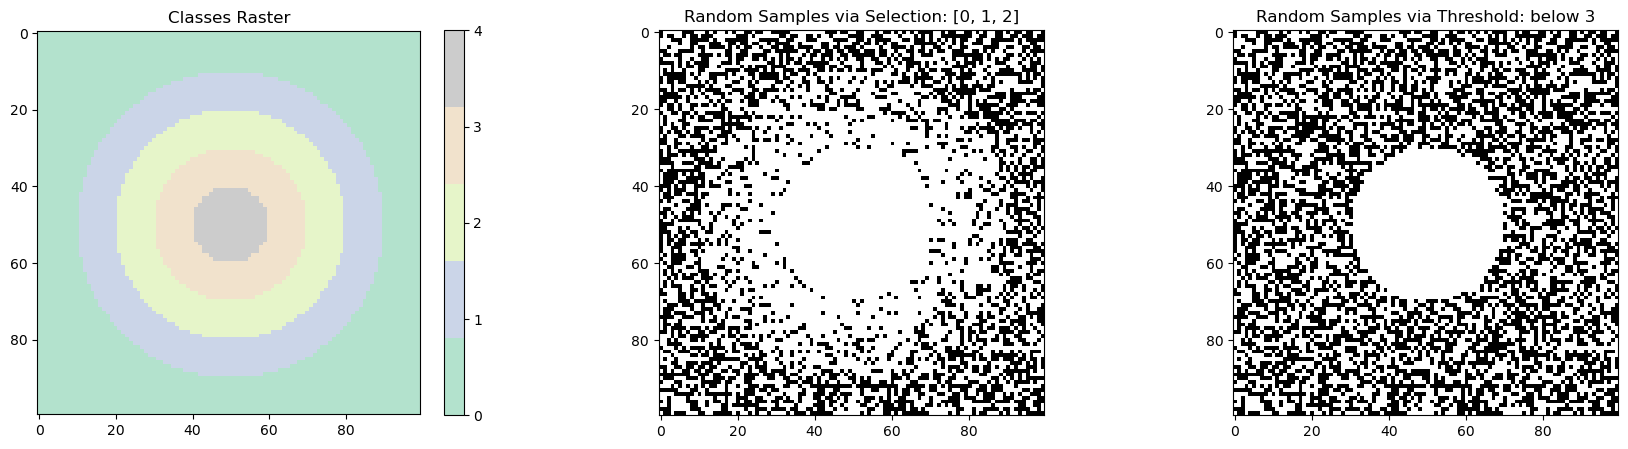

In [79]:
# Plot
ncols = 3
fig_size = ncols * 7

cats_values = np.unique(cats_array)
cats_cmap = plt.get_cmap("Pastel2", len(cats_values))
cats_ticks = cats_values
fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=(fig_size, 5))

cats_img = ax[0].imshow(cats_array, cmap=cats_cmap, interpolation='nearest')
cats_bar = fig.colorbar(cats_img, ax=ax[0], ticks=cats_ticks)
ax[0].set_title("Classes Raster")

cats_negative_samples_a = ax[1].imshow(new_negatives_a.squeeze(), cmap="gray", interpolation='nearest')
ax[1].set_title(f"Random Samples via Selection: {SELECTION}")

cats_negative_samples_b = ax[2].imshow(new_negatives_b.squeeze(), cmap="gray", interpolation='nearest')
ax[2].set_title(f"Random Samples via Threshold: below {THRESHOLD}")

plt.show()

### Positives

**Selection** of clusters in order for positive sampling can be done as follows:
- Threshold via `_sampling_by_treshold` and `type="positives"` with value **1** (selects all values equal or above)
- Quantile via `sampling_by_threshold` and `type="positives"` (**not** appropriate here)
- Discrete selection via `_sampling_by_selection` using the `include` parameter with value **[3,4]**
- Discrete selection via `_sampling_by_selection` using the `exclude` parameter with all values except **0**

**Please not that this procedure aims to create new positives**<br>
E.g., this means, the resulting pixels will be `value = 1` and remaining pixels will be `value = np.nan`.

In [80]:
SELECTION = [3, 4]
EXCLUDE = [0]
THRESHOLD = 3
TARGET_POSITIVES = 1
CLUSTER_MAP = cats_path

#### Option A
**Selection** using `_sampling_by_selection`

We use a **different sampling strategy** for each class, decreasing from outer to inner classes:<br>
- 25% for class 3
- 75% for class 4

In [81]:
from beak.experimental.preparation import _sampling_by_selection

# Selection of pixels not in class 0
selection_array_a, selection_settings_a = _sampling_by_selection(CLUSTER_MAP, include=SELECTION, exclude=EXCLUDE)

# Get unique values
selected_classes_a, selected_classes_counts_a = _get_unique_values_list(selection_array_a, include_nan=True, verbose=1)


Class: 3.0, Count: 940
Class: 4.0, Count: 305
Class: nan, Count: 8755


**Sampling**

In [82]:
from beak.experimental.preparation import _sampling_select_random_points

# Sampling
STRATEGY = [0.25, 0.75]
add_positives_a, pos_dict_a = _sampling_select_random_points(array=selection_array_a,     # the prepared array
                                                         selection=SELECTION,             # the classes to sample from
                                                         strategy=STRATEGY,               # the fraction to sample
                                                         target_value=TARGET_POSITIVES,   # the output value for sampled pixels
                                                         merge_classes=False,             # merge before sampling or not
                                                         min_px=1,                        # minimum number of pixels to sample
                                                         seed=42,                         # seed for reproducibility
)

# Get unique values
classes_a, counts_a = _get_unique_values_list(add_positives_a, include_nan=True, verbose=1)

Class: 1.0, Count: 464
Class: nan, Count: 9536


In [83]:
# Check fractions for classes
sum_px = 0
for _class, _count, _fraction in zip(selected_classes_a, selected_classes_counts_a, STRATEGY):
  print(f"Class: {_class}, count: {_count}, fraction: {_fraction}, number of pixels: {round(_count * _fraction)}")

  sum_px = sum_px + np.sum(_count * _fraction)

print(f"Total number of pixels: {int(round(sum_px))}")

Class: 3.0, count: 940, fraction: 0.25, number of pixels: 235
Class: 4.0, count: 305, fraction: 0.75, number of pixels: 229
Total number of pixels: 464


#### Option B
**Selection** using `_sampling_by_threshold`

We use the  **same sampling strategy** for each class, however, even using the `threshold` parameter, different strategies as in **Option A** can be used:<br>
- 25% for all selected classes

In [84]:
from beak.experimental.preparation import _sampling_by_threshold
selection_array_b, settings_b = _sampling_by_threshold(CLUSTER_MAP, type="positives", threshold=THRESHOLD)

# Get unique values
selected_classes_b, selected_classes_counts_b = _get_unique_values_list(selection_array_b, include_nan=True, verbose=1)


Class: 3.0, Count: 940
Class: 4.0, Count: 305
Class: nan, Count: 8755


**Sampling**

In [85]:
from beak.experimental.preparation import _sampling_select_random_points

# Sampling
STRATEGY = [0.25]
selection = [value for value in np.unique(selection_array_b) if not np.isnan(value)]

add_positives_b, pos_dict_b = _sampling_select_random_points(array=selection_array_b,           # the prepared array
                                                             selection=selection,               # the classes to sample from
                                                             strategy=STRATEGY,                 # the fraction to sample
                                                             target_value=TARGET_POSITIVES,     # the output value for sampled pixels
                                                             merge_classes=False,               # merge before sampling or not
                                                             min_px=1,                          # minimum number of pixels to sample
                                                             seed=42,                           # seed for reproducibility
)

# Get unique values
classes_b, counts_b = _get_unique_values_list(add_positives_b, include_nan=True, verbose=1)

Class: 1.0, Count: 311
Class: nan, Count: 9689


In [86]:
# Check fractions for classes
sum_px = 0
for _class, _count, _fraction in zip(selected_classes_b, selected_classes_counts_b, STRATEGY):
  print(f"Class: {_class}, count: {_count}, fraction: {_fraction}, number of pixels: {round(_count * _fraction)}")

  sum_px = sum_px + np.sum(_count * _fraction)

print(f"Total number of pixels: {int(round(sum_px))}")

Class: 3.0, count: 940, fraction: 0.25, number of pixels: 235
Total number of pixels: 235


#### Comparison

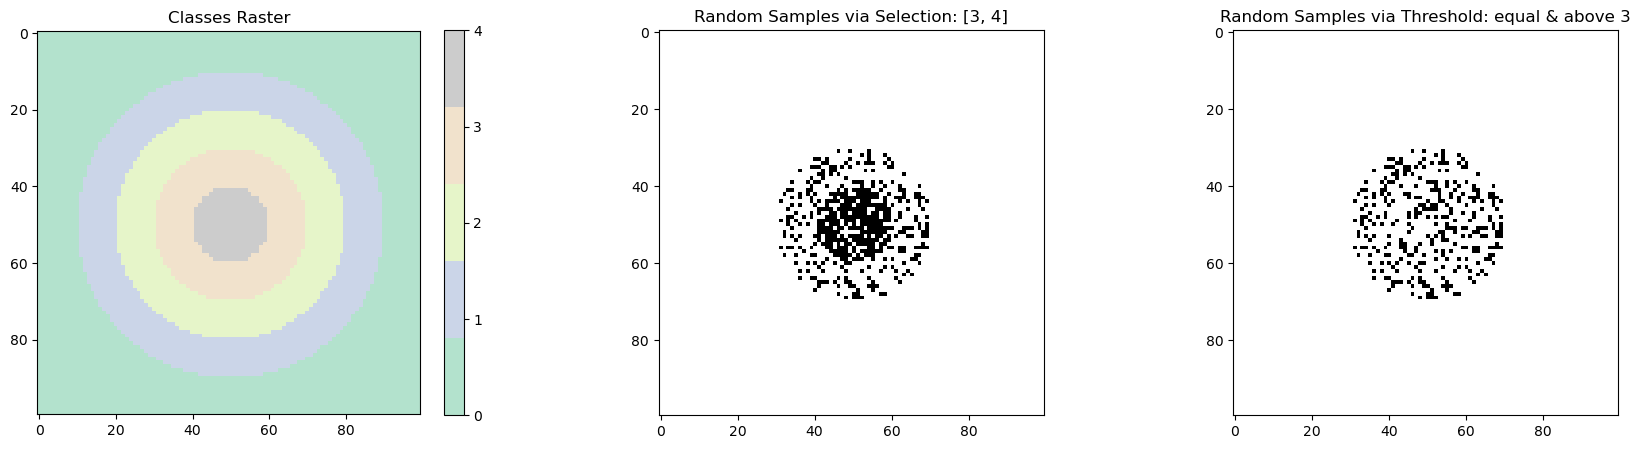

In [87]:
# Plot
ncols = 3
fig_size = ncols * 7

cats_values = np.unique(cats_array)
cats_cmap = plt.get_cmap("Pastel2", len(cats_values))
cats_ticks = cats_values
fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=(fig_size, 5))

cats_img = ax[0].imshow(cats_array, cmap=cats_cmap, interpolation="nearest")
cats_bar = fig.colorbar(cats_img, ax=ax[0], ticks=cats_ticks)
ax[0].set_title("Classes Raster")

cats_negative_samples_a = ax[1].imshow(add_positives_a.squeeze(), cmap="gray", interpolation="nearest")
ax[1].set_title(f"Random Samples via Selection: {SELECTION}")

cats_negative_samples_b = ax[2].imshow(add_positives_b.squeeze(), cmap="gray", interpolation="nearest")
ax[2].set_title(f"Random Samples via Threshold: equal & above {THRESHOLD}")

plt.show()

## Putting things together

**Merge** (with original labels)

<span style="color:red">**Hint**</span>.
The count of the resulting `new_labels_positives` and the sum of its ingredients `original_labels_positives` and `new_labels_positives` must not neccessarily be equal.<br>
This is because the locations of some **additional** and **original** labels might be the same.

In [102]:
# Select an option (A/B) from above
selected_negatives = new_negatives_b
selected_positives = add_positives_b

# Prepare original labels: Set negative samples to NaN
new_labels_array = np.copy(labels_array)
new_labels_array = np.where(new_labels_array == TARGET_NEGATIVES, np.nan, new_labels_array)

# Add new negative samples to existing labels
new_labels_array = np.where(selected_negatives == TARGET_NEGATIVES, TARGET_NEGATIVES, new_labels_array)

# Add new positive samples to existing labels
new_labels_array = np.where(selected_positives == TARGET_POSITIVES, TARGET_POSITIVES, new_labels_array)

# Add original labels to new labels, in case some got overwritten
new_labels_array = np.where(labels_array == TARGET_POSITIVES, TARGET_POSITIVES, new_labels_array)

In [118]:
# Get the numbers
num_original_positives = np.sum(labels_array == TARGET_POSITIVES)
num_addition_positives = np.sum(selected_positives == TARGET_POSITIVES)
num_new_labels_positives = np.sum(new_labels_array == TARGET_POSITIVES)

print(f"Number of original positives: {num_original_positives}")
print(f"Number of added positives: {num_addition_positives}")

# Check the numbers
print(f"Number of new labels positives: {num_new_labels_positives}")

# Check numbers of overlapping positives
overlapping_positives = labels_array + selected_positives
print(f"Number of overlapping positives: {np.sum(overlapping_positives == TARGET_POSITIVES*2)}")

Number of original positives: 181
Number of added positives: 311
Number of new labels positives: 486
Number of overlapping positives: 6


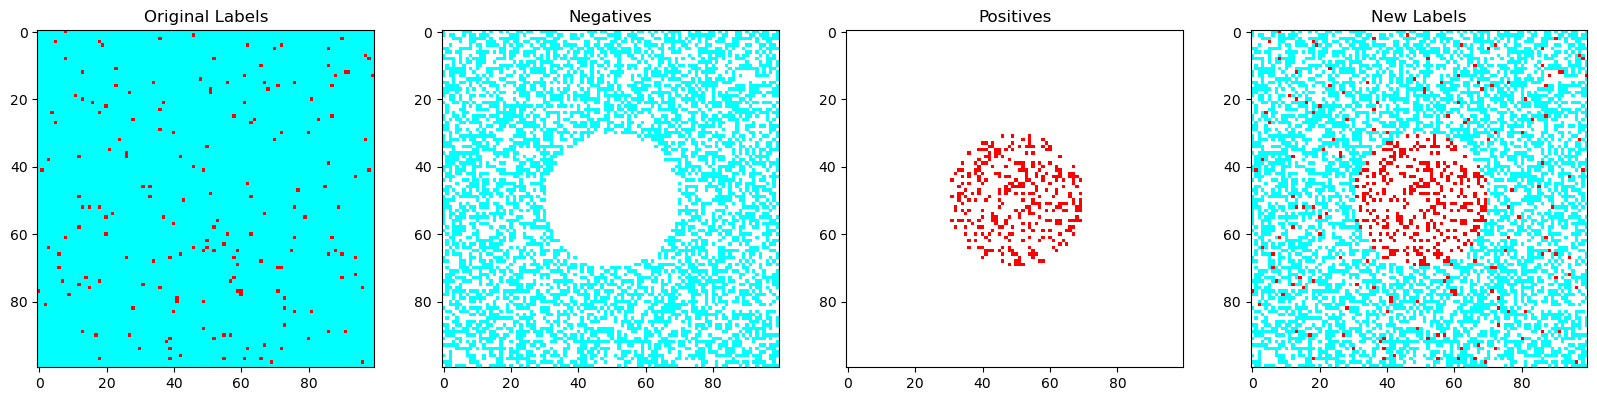

In [130]:
from matplotlib.colors import ListedColormap

# Plot
ncols = 4
fig_size = ncols * 5

fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=(fig_size, 5))

color_positives = "red"
color_negatives = "cyan"

cmap_original = ListedColormap([color_negatives, color_positives])
ax[0].imshow(labels_array, cmap=cmap_original)
ax[0].set_title("Original Labels")

cmap_negatives = ListedColormap([color_negatives])
ax[1].imshow(new_negatives_b.squeeze(), cmap=cmap_negatives)
ax[1].set_title(f"Negatives")

cmap_positives = ListedColormap([color_positives])
ax[2].imshow(add_positives_b.squeeze(), cmap=cmap_positives)
ax[2].set_title(f"Positives")

ax[3].imshow(new_labels_array.squeeze(), cmap=cmap_original)
ax[3].set_title(f"New Labels")


plt.show()

**Save**

In [131]:
# Save extended positive labels
from beak.utilities.file_io import save_raster, prepare_output

out_path = os.path.join(data_folder, "labels_cats_negatives.tif")
out_raster, out_meta = prepare_output(selected_negatives, labels_meta)
save_raster(out_raster, out_meta, out_path)

out_path = os.path.join(data_folder, "labels_cats_positives.tif")
out_raster, out_meta = prepare_output(selected_positives, labels_meta)
save_raster(out_raster, out_meta, out_path)

out_path = os.path.join(data_folder, "labels_cats_new_labels.tif")
out_raster, out_meta = prepare_output(new_labels_array, labels_meta)
save_raster(out_raster, out_meta, out_path)
